In [55]:
import sys
sys.path.append('..')

from src.visualization import plot_settings
import pandas as pd
import numpy as np
import seaborn as sns

df = pd.read_csv('../data/processed/df.csv')
print('N =', len(df.prolificID.unique()))

N = 245


In [56]:

try:
    df_fit = pd.read_csv('../data/processed/omega_fit_full.csv')
    df = df.drop(columns=['group'], errors='ignore').merge(df_fit[['prolificID', 'group']], on='prolificID', how='left')

except FileNotFoundError:
    raise FileNotFoundError("Please run 0.3-fit.ipynb to generate omega_fit_full.csv")



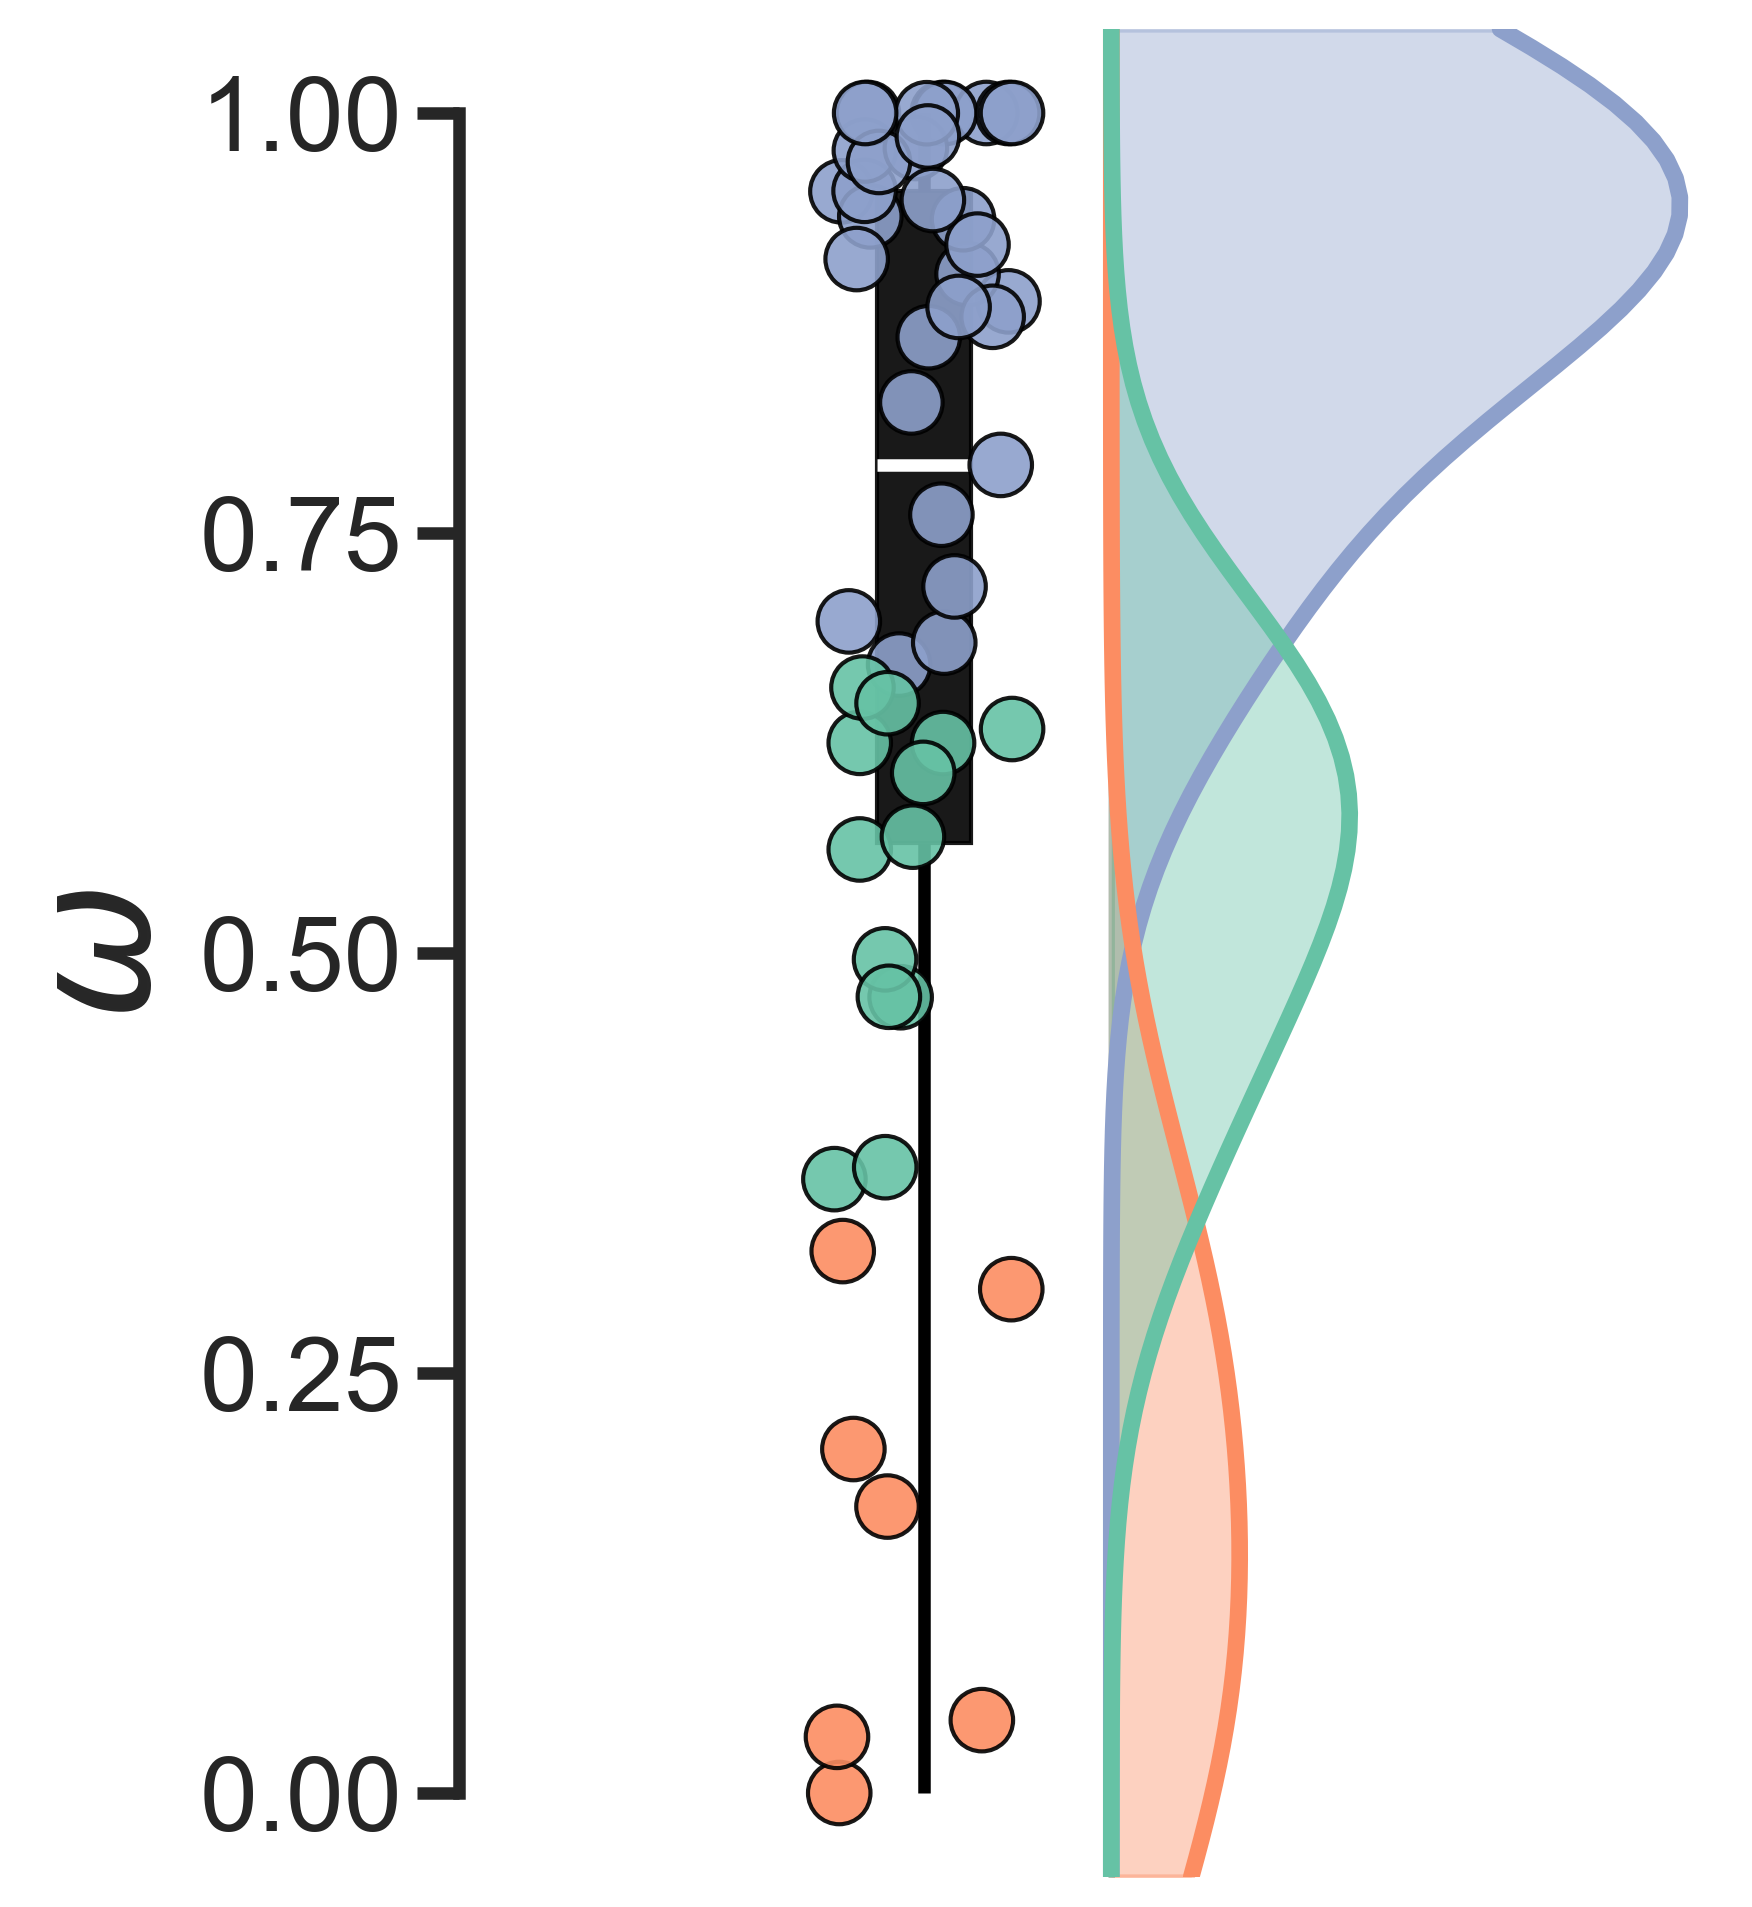

In [48]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats

np.random.seed(42)

exp_ = 'exp1'
delta = df_fit[(df_fit.model=='map') & (df_fit.exp==exp_) & (df_fit.group!='random')].groupby(['agent', 'group', 'model', 'exp']).last().reset_index()

dd2 = pd.DataFrame({
    'agent': delta.agent.values,
    'expName': delta.exp,
    'group': delta.group.values,
    'model': delta.model.values,
    'delta': delta.omega.values,
    'll': delta.ll.values,
})

dd2 = dd2[(dd2.expName==exp_) & (dd2.group.isin(['value', 'perceptual', 'combined']))]
groups = sorted(dd2.group.unique(), key=lambda x: ['perceptual', 'value', 'combined'].index(x))

palette = sns.color_palette('Set2')
palette = [palette[2], palette[1], palette[0]]
dot_position = -.5
kde_start = 0.2

sns.set_style('ticks')
sns.set_context('talk')
plt.figure(figsize=(4, 8), dpi=300)

sns.boxplot(y='delta', data=dd2, color='black', width=0.1, x=np.ones(len(dd2))*dot_position,
            boxprops=dict(facecolor='black', zorder=1, alpha=0.9),
            whiskerprops=dict(color='black', zorder=1, linewidth=3),
            capprops=dict(color='black', zorder=1, linewidth=0),
            medianprops=dict(color='white', zorder=2, linewidth=3),
            showfliers=False,
            saturation=1,
            ax=plt.gca()
            )

sns.stripplot(data=dd2, x=np.ones(len(dd2))*dot_position, y='delta', hue='group',
              hue_order=groups, palette=palette,
              edgecolor='black', size=15, linewidth=1, alpha=0.9, zorder=2)

plt.ylim(-.05, 1.05)

x_pts = np.linspace(dd2.delta.min() - 0.05, dd2.delta.max() + 0.05, 100)
overall_kde = stats.gaussian_kde(dd2['delta'].values, bw_method=1)
overall_density = overall_kde(x_pts)
max_overall_density = overall_density.max()

for i, group_name in enumerate(groups):
    subset = dd2[dd2.group == group_name]
    group_kde = stats.gaussian_kde(subset['delta'].values, bw_method=1)
    group_density = group_kde(x_pts)
    scaled_density = (group_density / group_density.max()) * len(subset) / len(dd2) * max_overall_density**0.1
    plt.fill_betweenx(x_pts, kde_start, kde_start + scaled_density, color=palette[i], alpha=0.4)
    plt.plot(kde_start + scaled_density, x_pts, color=palette[i], lw=4)

plt.xticks([], [])
plt.yticks(np.arange(0, 1.1, .25), fontsize=40)
plt.legend().remove()

sns.despine(trim=True, bottom=True, offset=80)
plt.xlabel('')
plt.ylabel('$\\omega$', fontdict={'fontsize': 40})
plt.yticks(fontsize=25)
plt.gca().spines['left'].set_linewidth(3)
plt.gca().tick_params(width=3, length=10)


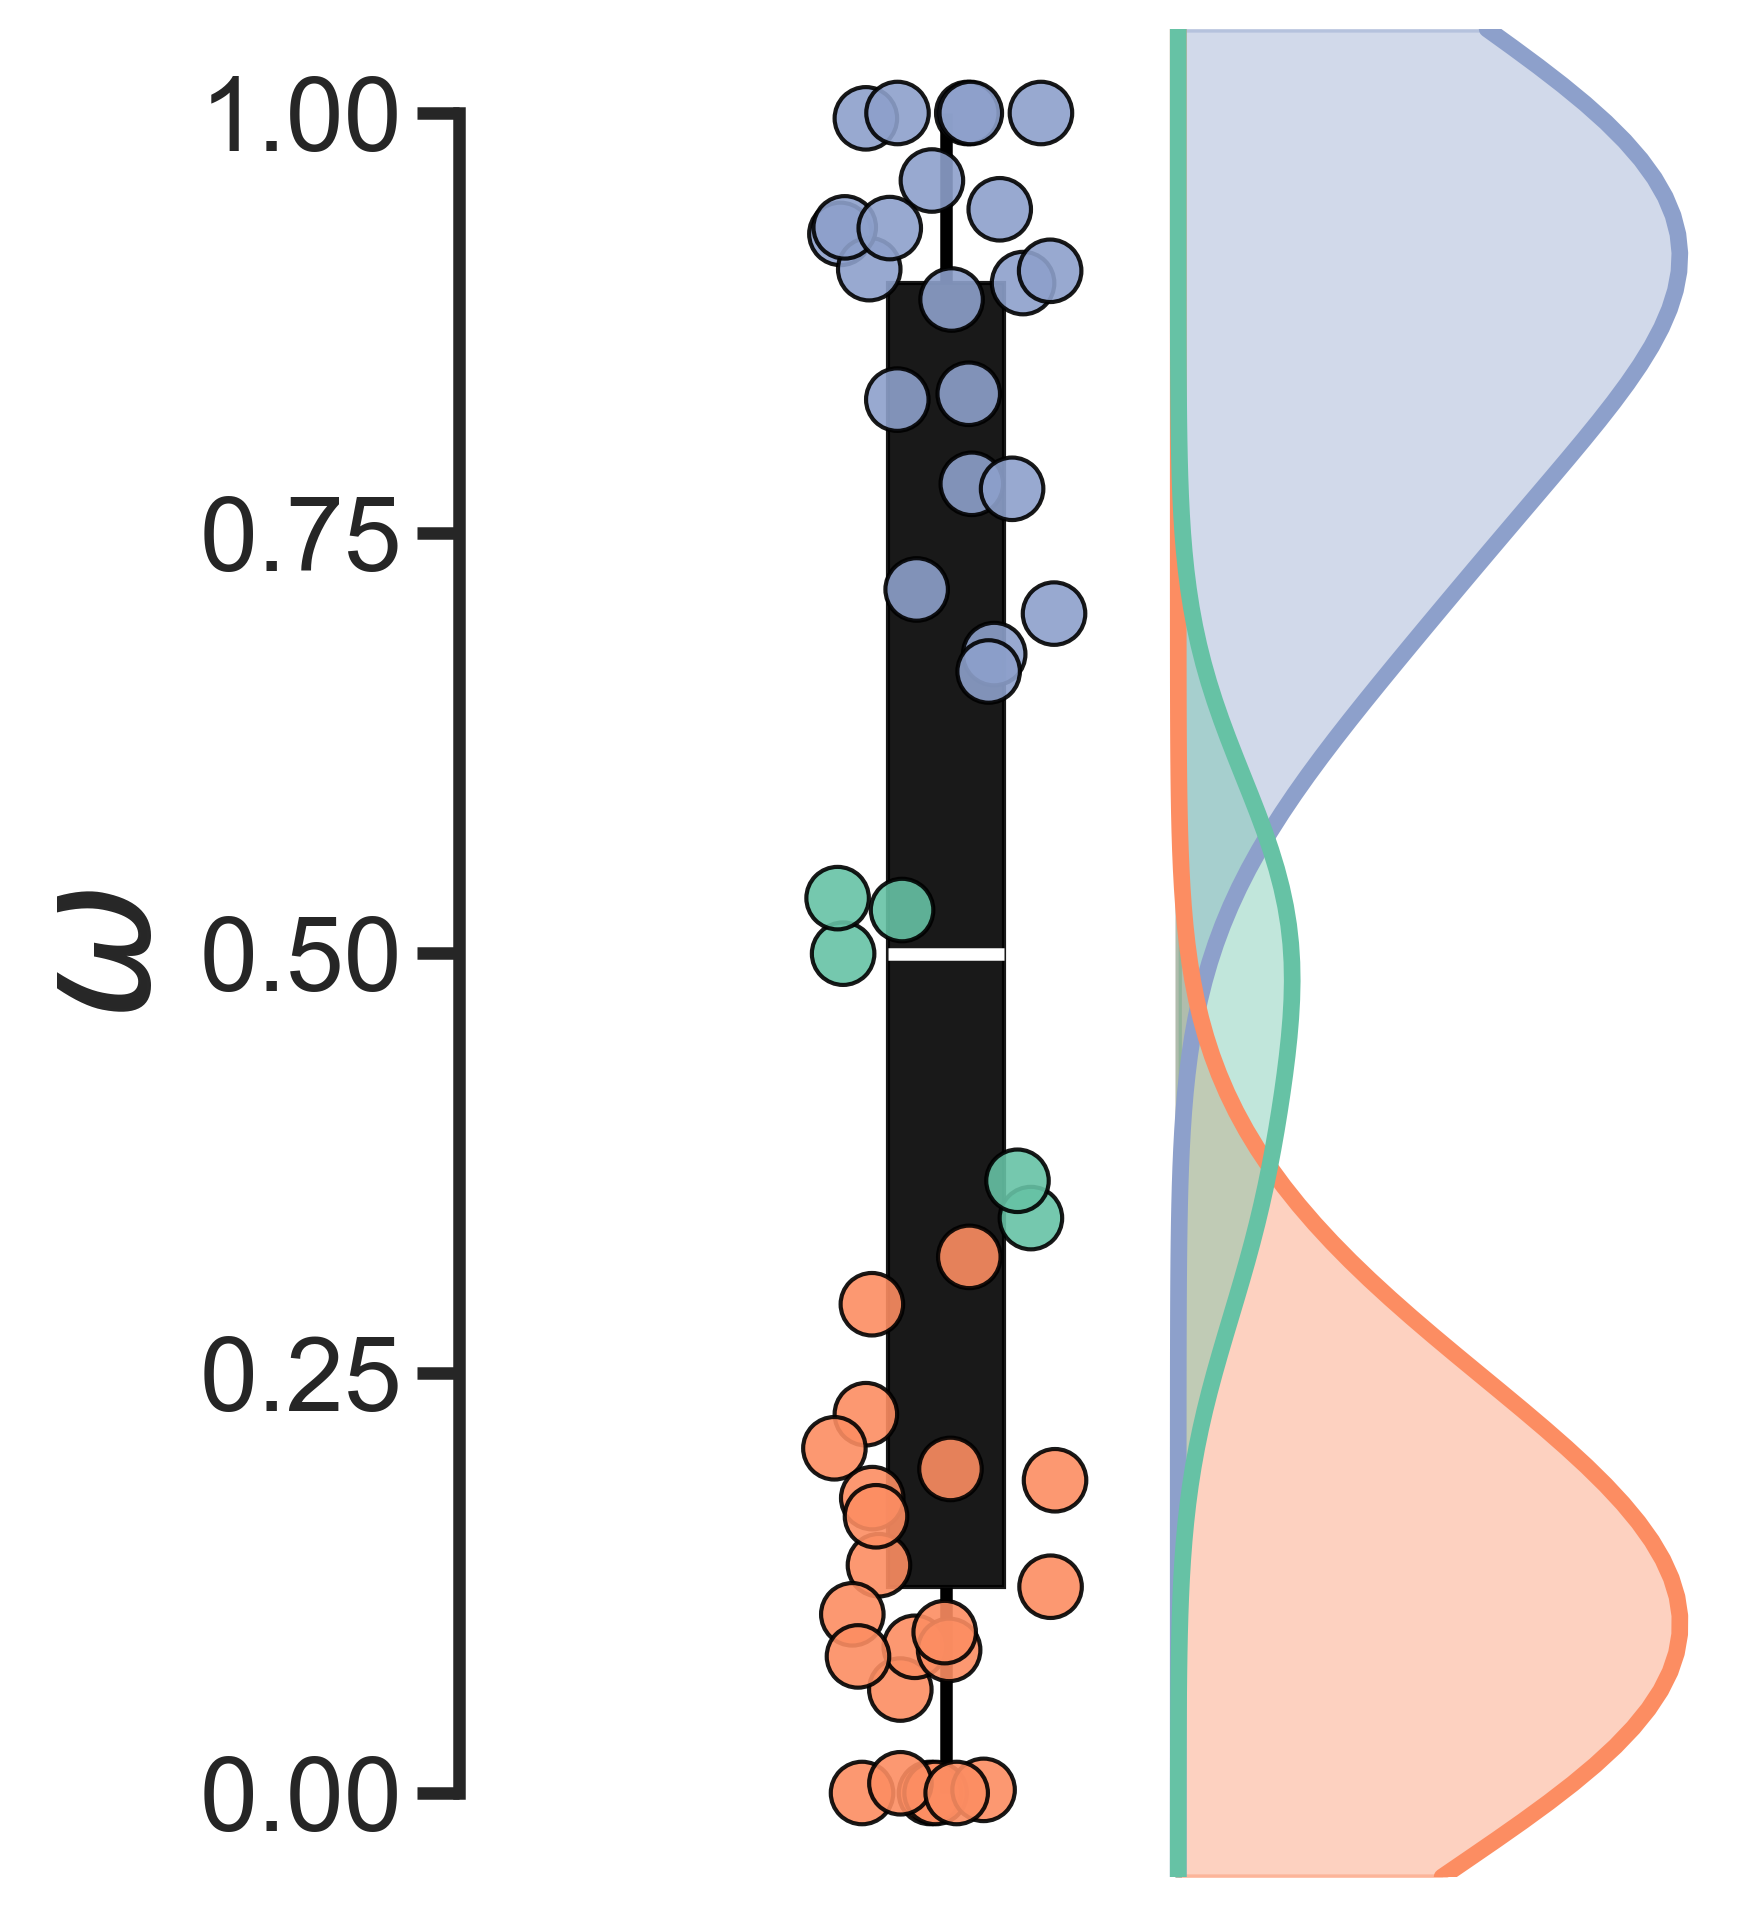

In [49]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats

np.random.seed(42)

exp_ = 'exp2'
delta = df_fit[(df_fit.model=='map') & (df_fit.exp==exp_) & (df_fit.group!='random')].groupby(['agent', 'group', 'model', 'exp']).last().reset_index()

dd2 = pd.DataFrame({
    'agent': delta.agent.values,
    'expName': delta.exp,
    'group': delta.group.values,
    'model': delta.model.values,
    'delta': delta.omega.values,
    'll': delta.ll.values,
})

dd2 = dd2[(dd2.expName==exp_) & (dd2.group.isin(['value', 'perceptual', 'combined']))]
groups = sorted(dd2.group.unique(), key=lambda x: ['perceptual', 'value', 'combined'].index(x))

palette = sns.color_palette('Set2')
palette = [palette[2], palette[1], palette[0]]
dot_position = -.5
kde_start = 0.2

sns.set_style('ticks')
sns.set_context('talk')
plt.figure(figsize=(4, 8), dpi=300)

sns.boxplot(y='delta', data=dd2, color='black', width=0.1, x=np.ones(len(dd2))*dot_position,
            boxprops=dict(facecolor='black', zorder=1, alpha=0.9),
            whiskerprops=dict(color='black', zorder=1, linewidth=3),
            capprops=dict(color='black', zorder=1, linewidth=0),
            medianprops=dict(color='white', zorder=2, linewidth=3),
            showfliers=False,
            saturation=1,
            ax=plt.gca()
            )

sns.stripplot(data=dd2, x=np.ones(len(dd2))*dot_position, y='delta', hue='group',
              hue_order=groups, palette=palette,
              edgecolor='black', size=15, linewidth=1, alpha=0.9, zorder=2)

plt.ylim(-.05, 1.05)

x_pts = np.linspace(dd2.delta.min() - 0.05, dd2.delta.max() + 0.05, 100)
overall_kde = stats.gaussian_kde(dd2['delta'].values, bw_method=1)
overall_density = overall_kde(x_pts)
max_overall_density = overall_density.max()

for i, group_name in enumerate(groups):
    subset = dd2[dd2.group == group_name]
    group_kde = stats.gaussian_kde(subset['delta'].values, bw_method=1)
    group_density = group_kde(x_pts)
    scaled_density = (group_density / group_density.max()) * len(subset) / len(dd2) * max_overall_density**0.1
    plt.fill_betweenx(x_pts, kde_start, kde_start + scaled_density, color=palette[i], alpha=0.4)
    plt.plot(kde_start + scaled_density, x_pts, color=palette[i], lw=4)

plt.xticks([], [])
plt.yticks(np.arange(0, 1.1, .25), fontsize=40)
plt.legend().remove()

sns.despine(trim=True, bottom=True, offset=80)
plt.xlabel('')
plt.ylabel('$\\omega$', fontdict={'fontsize': 40})
plt.yticks(fontsize=25)
plt.gca().spines['left'].set_linewidth(3)
plt.gca().tick_params(width=3, length=10)


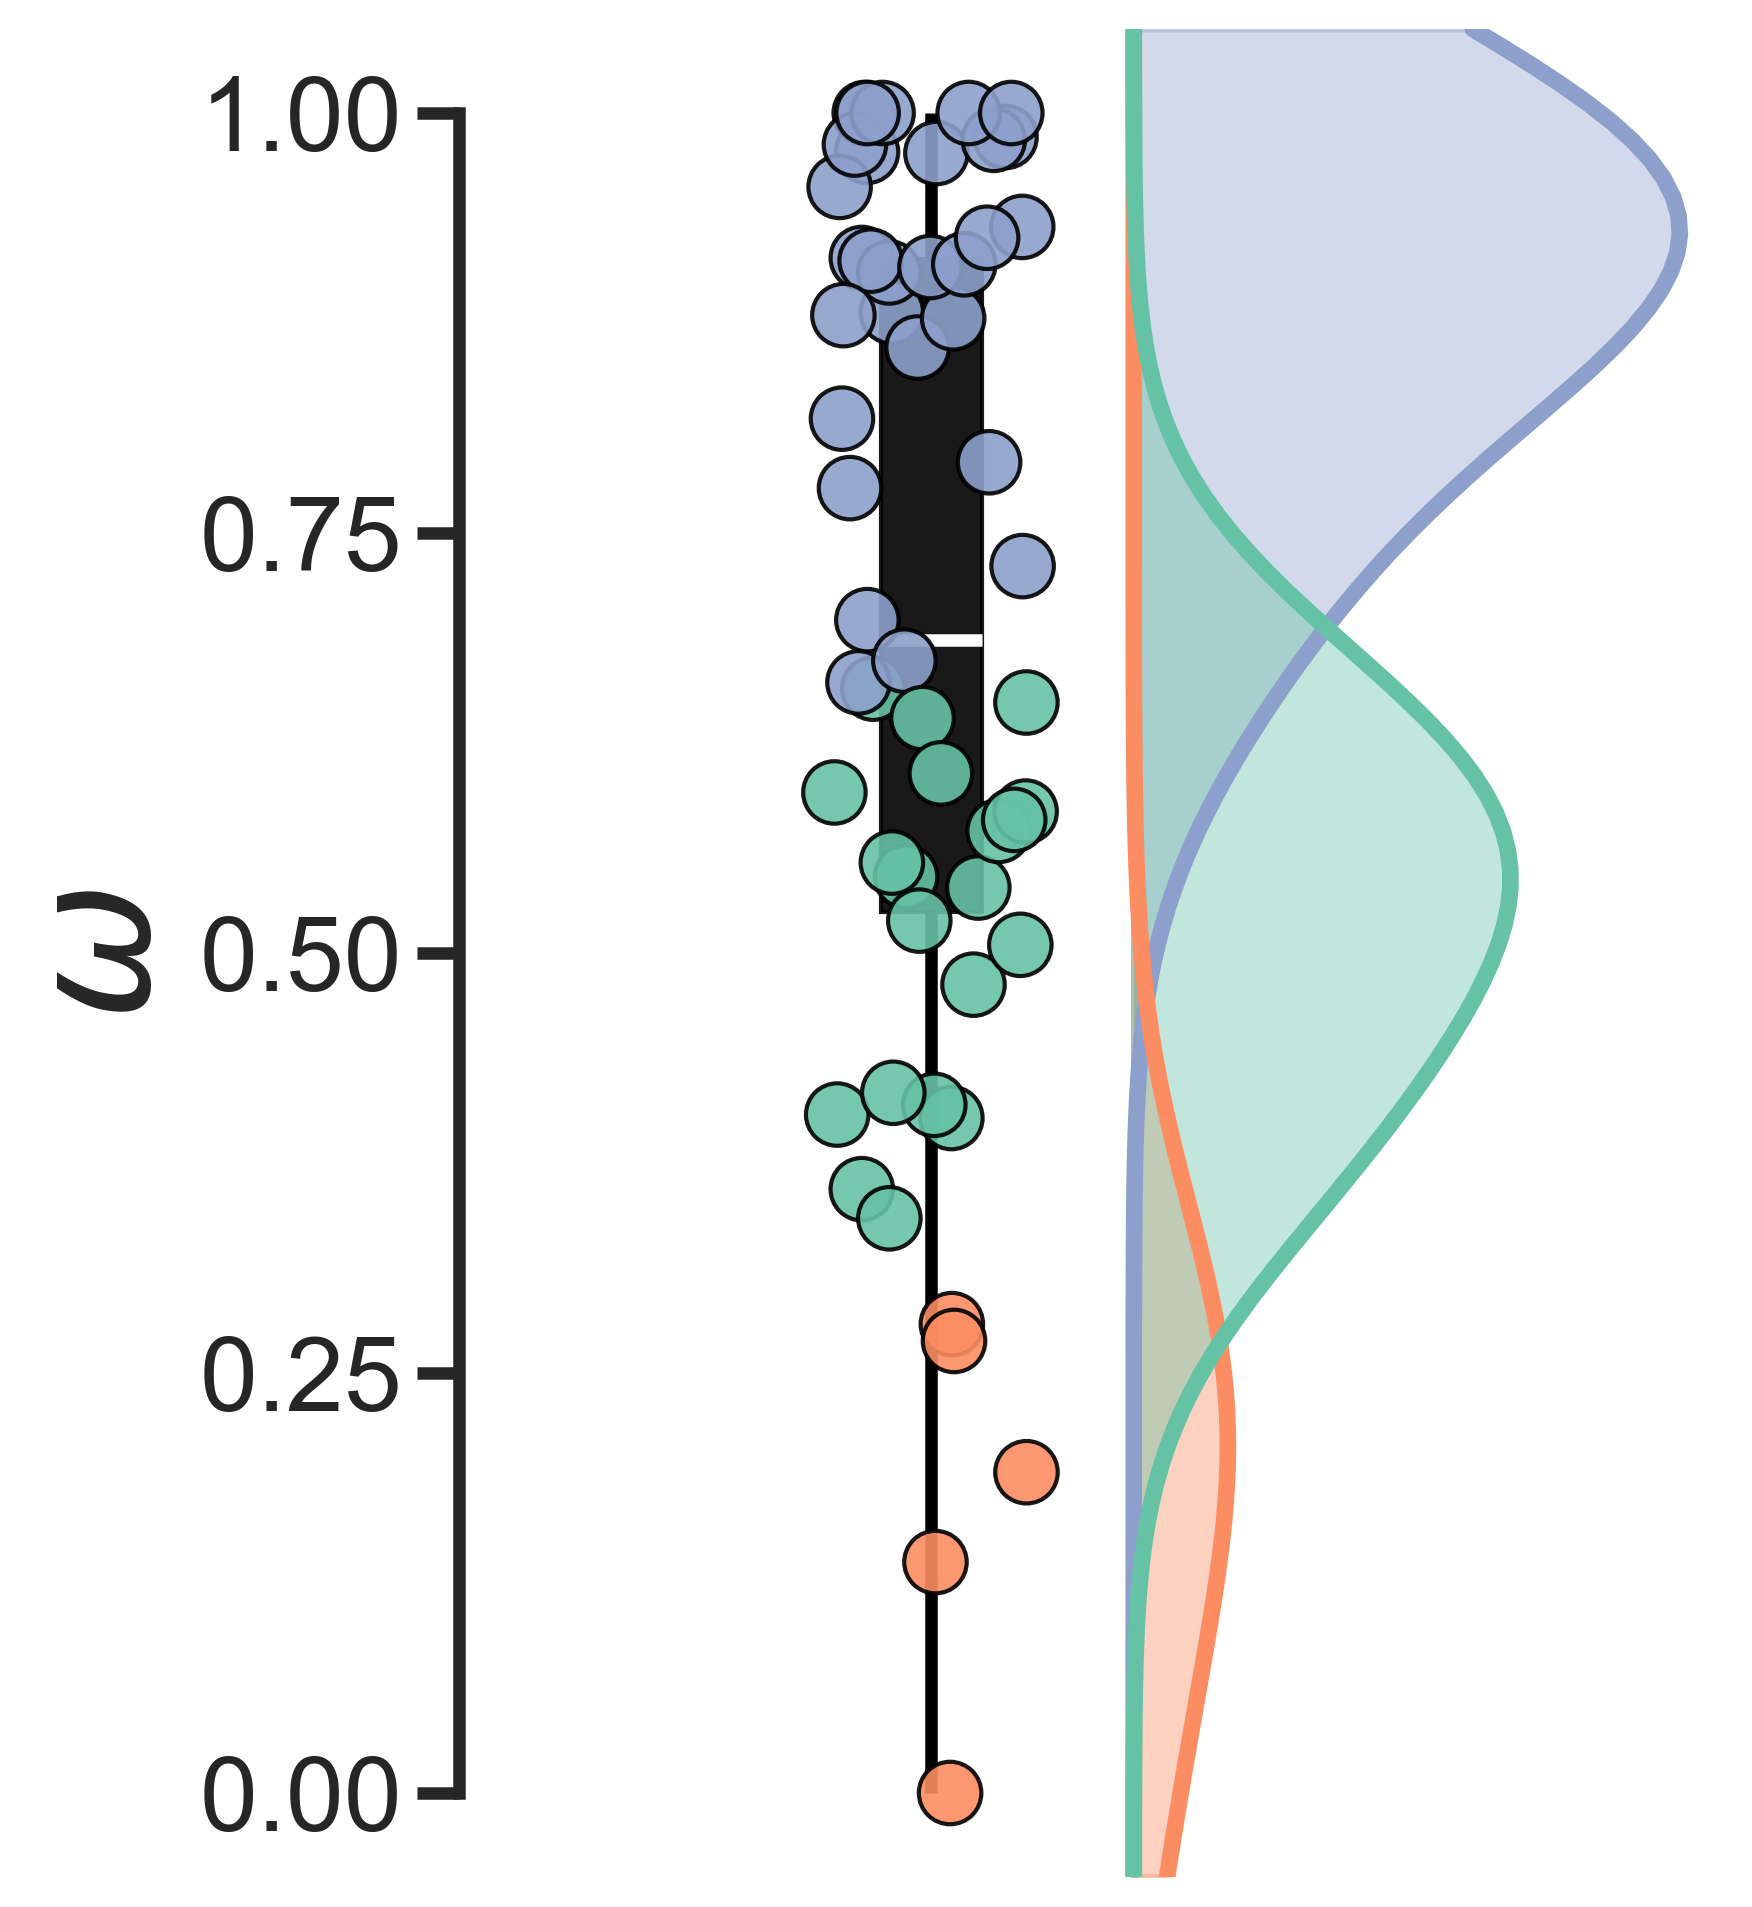

In [50]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats

np.random.seed(42)

exp_ = 'exp3'
delta = df_fit[(df_fit.model=='map') & (df_fit.exp==exp_) & (df_fit.group!='random')].groupby(['agent', 'group', 'model', 'exp']).last().reset_index()

dd2 = pd.DataFrame({
    'agent': delta.agent.values,
    'expName': delta.exp,
    'group': delta.group.values,
    'model': delta.model.values,
    'delta': delta.omega.values,
    'll': delta.ll.values,
})

dd2 = dd2[(dd2.expName==exp_) & (dd2.group.isin(['value', 'perceptual', 'combined']))]
groups = sorted(dd2.group.unique(), key=lambda x: ['perceptual', 'value', 'combined'].index(x))

palette = sns.color_palette('Set2')
palette = [palette[2], palette[1], palette[0]]
dot_position = -.5
kde_start = 0.2

sns.set_style('ticks')
sns.set_context('talk')
plt.figure(figsize=(4, 8), dpi=300)

sns.boxplot(y='delta', data=dd2, color='black', width=0.1, x=np.ones(len(dd2))*dot_position,
            boxprops=dict(facecolor='black', zorder=1, alpha=0.9),
            whiskerprops=dict(color='black', zorder=1, linewidth=3),
            capprops=dict(color='black', zorder=1, linewidth=0),
            medianprops=dict(color='white', zorder=2, linewidth=3),
            showfliers=False,
            saturation=1,
            ax=plt.gca()
            )

sns.stripplot(data=dd2, x=np.ones(len(dd2))*dot_position, y='delta', hue='group',
              hue_order=groups, palette=palette,
              edgecolor='black', size=15, linewidth=1, alpha=0.9, zorder=2)

plt.ylim(-.05, 1.05)

x_pts = np.linspace(dd2.delta.min() - 0.05, dd2.delta.max() + 0.05, 100)
overall_kde = stats.gaussian_kde(dd2['delta'].values, bw_method=1)
overall_density = overall_kde(x_pts)
max_overall_density = overall_density.max()

for i, group_name in enumerate(groups):
    subset = dd2[dd2.group == group_name]
    group_kde = stats.gaussian_kde(subset['delta'].values, bw_method=1)
    group_density = group_kde(x_pts)
    scaled_density = (group_density / group_density.max()) * len(subset) / len(dd2) * max_overall_density**0.1
    plt.fill_betweenx(x_pts, kde_start, kde_start + scaled_density, color=palette[i], alpha=0.4)
    plt.plot(kde_start + scaled_density, x_pts, color=palette[i], lw=4)

plt.xticks([], [])
plt.yticks(np.arange(0, 1.1, .25), fontsize=40)
plt.legend().remove()

sns.despine(trim=True, bottom=True, offset=80)
plt.xlabel('')
plt.ylabel('$\\omega$', fontdict={'fontsize': 40})
plt.yticks(fontsize=25)
plt.gca().spines['left'].set_linewidth(3)
plt.gca().tick_params(width=3, length=10)


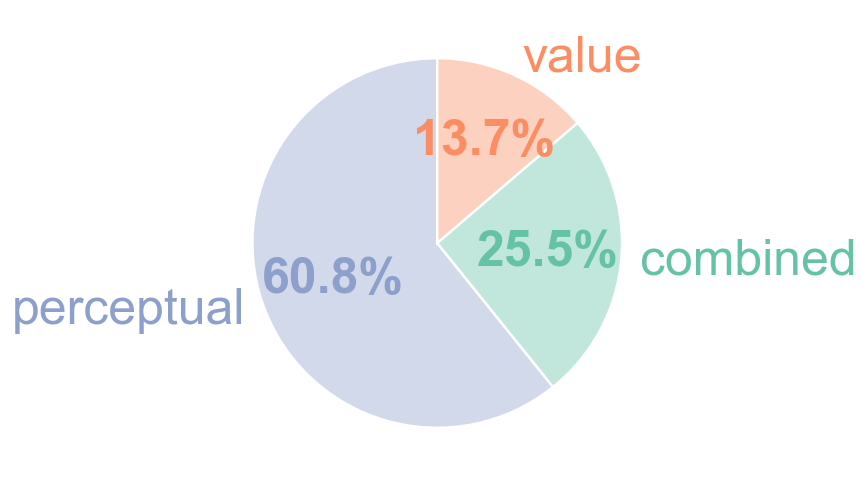

In [51]:
import seaborn as sns
import matplotlib.pyplot as plt


sns.set_palette('Set2')
# Data
groups =  ['perceptual', 'combined', 'value']
exp = 'exp1'
means = df_fit[(df_fit.exp==exp) & (df_fit.group!='random')].groupby('prolificID').last().group.value_counts(normalize=True)
means = means.reindex(groups, fill_value=0)  # Ensures all groups exist in the expected order
# sort means by groups
means = means.loc[groups].values
# Explode Shoes slice
# explode = (0, 0.1, 0)  # Explode each slice slightly

colors = ['C2', 'C0', 'C1']
# colors with alpha = 0.5
colors2 = [(r, g, b, 0.4) for r, g, b in sns.color_palette('Set2')]
# select 0, 2, 7, 1
colors2 = [colors2[i] for i in [2, 0, 1]]

# Create pie chart
wedges, texts, autotexts = plt.pie(means, labels=groups,  colors=colors2, autopct='%1.1f%%', startangle=90)

for i, autotext in enumerate(autotexts):
    autotext.set_color(colors[i])
    autotext.set_fontsize(30)
    autotext.set_fontweight('bold')

for i, text in enumerate(texts):
    text.set_color(colors[i])
    text.set_fontsize(30)



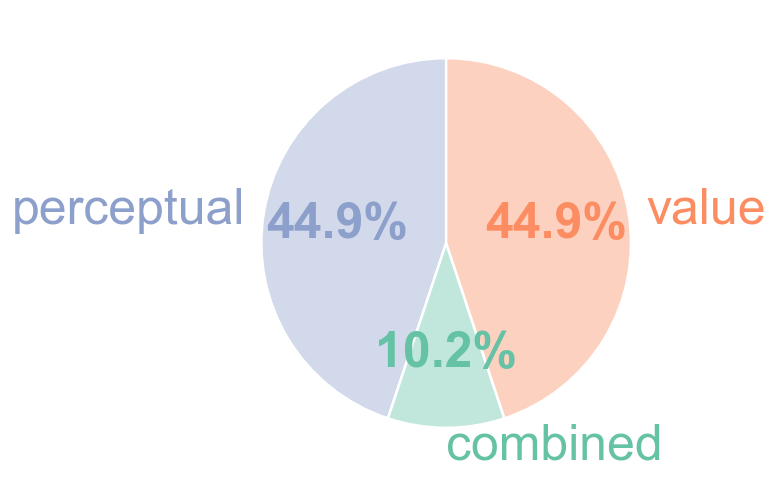

In [52]:
import seaborn as sns
import matplotlib.pyplot as plt


sns.set_palette('Set2')
# Data
groups =  ['perceptual', 'combined', 'value']
exp = 'exp2'
means = df_fit[(df_fit.exp==exp) & (df_fit.group!='random')].groupby('prolificID').last().group.value_counts(normalize=True)
means = means.reindex(groups, fill_value=0)  # Ensures all groups exist in the expected order
# sort means by groups
means = means.loc[groups].values
# Explode Shoes slice
# explode = (0, 0.1, 0)  # Explode each slice slightly

colors = ['C2', 'C0', 'C1']
# colors with alpha = 0.5
colors2 = [(r, g, b, 0.4) for r, g, b in sns.color_palette('Set2')]
# select 0, 2, 7, 1
colors2 = [colors2[i] for i in [2, 0, 1]]

# Create pie chart
wedges, texts, autotexts = plt.pie(means, labels=groups,  colors=colors2, autopct='%1.1f%%', startangle=90)

for i, autotext in enumerate(autotexts):
    autotext.set_color(colors[i])
    autotext.set_fontsize(30)
    autotext.set_fontweight('bold')

for i, text in enumerate(texts):
    text.set_color(colors[i])
    text.set_fontsize(30)



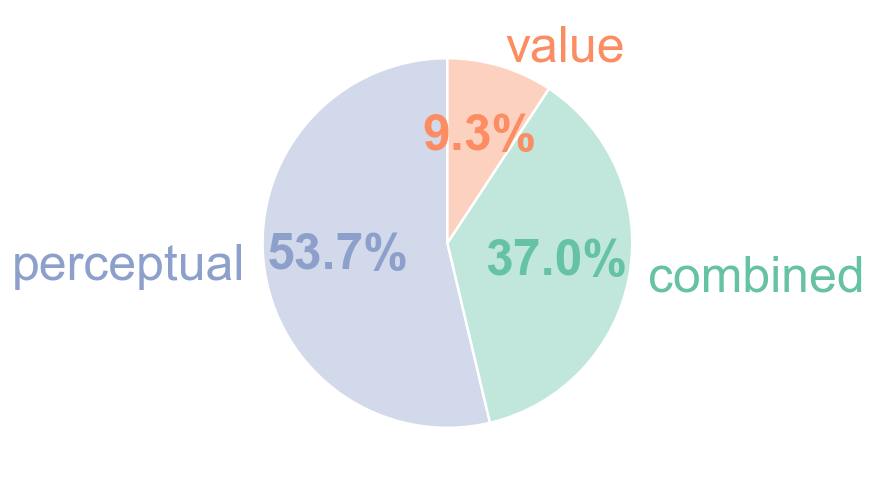

In [53]:
import seaborn as sns
import matplotlib.pyplot as plt


sns.set_palette('Set2')
# Data
groups =  ['perceptual', 'combined', 'value']
exp = 'exp3'
means = df_fit[(df_fit.exp==exp) & (df_fit.group!='random')].groupby('prolificID').last().group.value_counts(normalize=True)
means = means.reindex(groups, fill_value=0)  # Ensures all groups exist in the expected order
# sort means by groups
means = means.loc[groups].values
# Explode Shoes slice
# explode = (0, 0.1, 0)  # Explode each slice slightly

colors = ['C2', 'C0', 'C1']
# colors with alpha = 0.5
colors2 = [(r, g, b, 0.4) for r, g, b in sns.color_palette('Set2')]
# select 0, 2, 7, 1
colors2 = [colors2[i] for i in [2, 0, 1]]

# Create pie chart
wedges, texts, autotexts = plt.pie(means, labels=groups,  colors=colors2, autopct='%1.1f%%', startangle=90)

for i, autotext in enumerate(autotexts):
    autotext.set_color(colors[i])
    autotext.set_fontsize(30)
    autotext.set_fontweight('bold')

for i, text in enumerate(texts):
    text.set_color(colors[i])
    text.set_fontsize(30)



In [54]:
import pingouin as pg
import numpy as np
import pandas as pd

df2 = df_fit[df_fit.exp.isin(['exp1', 'exp2', 'exp3'])].groupby(['exp', 'group', 'prolificID']).last().reset_index()
# Chi-square test - returns (expected, observed, stats)
expected, observed, stats = pg.chi2_independence(data=df2, x='exp', y='group')

# Extract chi2 and p-value from the stats DataFrame (using Pearson test, first row)
chi2_stat = stats.loc[0, 'chi2']
p_val = stats.loc[0, 'pval']
dof = stats.loc[0, 'dof']
cramers_v = stats.loc[0, 'cramer']

# Format p-value
p_str = f"= {p_val:.3f}"

print(f"χ²({int(dof)}) = {chi2_stat:.2f}, p {p_str}, V = {cramers_v:.3f}")

# Display full results
print(f"\nStats DataFrame:\n{stats}")
print(f"\nExpected frequencies:\n{expected}")
print(f"\nObserved frequencies:\n{observed}")

χ²(6) = 26.51, p = 0.000, V = 0.264

Stats DataFrame:
                 test    lambda       chi2  dof      pval    cramer     power
0             pearson  1.000000  26.511271  6.0  0.000179  0.264133  0.787042
1        cressie-read  0.666667  26.325269  6.0  0.000194  0.263205  0.783672
2      log-likelihood  0.000000  26.589251  6.0  0.000173  0.264522  0.788442
3       freeman-tukey -0.500000  27.386761  6.0  0.000123  0.268459  0.802358
4  mod-log-likelihood -1.000000  28.775236  6.0  0.000067  0.275180  0.824854
5              neyman -2.000000  33.832363  6.0  0.000007  0.298383  0.889877

Expected frequencies:
group  combined  perceptual     random      value
exp                                              
exp1       12.2   26.326316  11.557895  10.915789
exp2       12.8   27.621053  12.126316  11.452632
exp3       13.0   28.052632  12.315789  11.631579

Observed frequencies:
group  combined  perceptual  random  value
exp                                       
exp1         13   